In [11]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout

import matplotlib as mpl
import matplotlib.pyplot as plt

import keras_tuner as kt
from tensorflow.keras import optimizers
from sklearn.model_selection import KFold
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 0
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


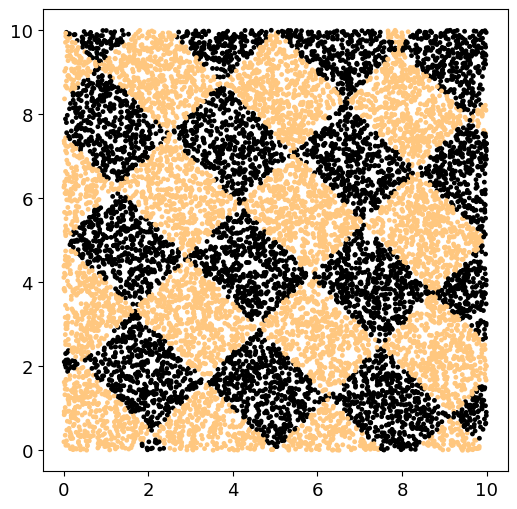

In [3]:

TYPE=4
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

In [5]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0) def plot_best_trials(self, num_models=5, wrap_columns=4, figure_size=(20,5), suffix=""):
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))np.random.seed(12345)

Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
 def plot_best_trials(self, num_models=5, wrap_columns=4, figure_size=(20,5), suffix=""):
        best_trials = self.oracle.get_best_trials(num_models)
        num_trials = len(best_trials)

        rows = (num_trials - 1) // wrap_columns + 1
        cols = min(num_trials, wrap_columns)

        fig, axes = plt.subplots(rows, cols, figsize=figure_size, layout='constrained')

        for i, trial in enumerate(best_trials):
            trial_id = trial.trial_id
            trial_dir = self.get_trial_dir(trial_id)
            history_file = os.path.join(trial_dir, "history.json")

            with open(history_file, "r") as f:
                trial_history = json.load(f)

            ax = axes[i // cols, i % cols] if rows > 1 else axes[i]
            for metric_name, metric_values in trial_history.items():
                ax.plot(metric_values, label=f"{metric_name}")

            ax.set_title(f"Trial {trial_id}")
            ax.set_xlabel("Step")
            ax.set_ylabel("Value")
            ax.yaxis.set_major_locator(MultipleLocator(0.1))
            ax.set_xlim(0, 400)
            ax.legend(fontsize=9)

In [24]:


np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

def build_model_tuning(hp):
    model = Sequential()
    activation_choice = hp.Choice('activation', values=['relu', 'elu', 'sigmoid'])
    droput_choice = hp.Choice('dropout', values=[0.0, 0.1, 0.2])
    lr_choice = hp.Choice('learning_rate', values=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'nesterov'])


    model.add(Dense(L,input_shape=(L,),activation=activation_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    model.add(Dense(20,activation=activation_choice))
    model.add(Dropout(droput_choice))
    model.add(Dense(1,activation=activation_choice))
   


    # 3. Impostiamo l'ottimizzatore per variare il learning rate
    if optimizer_choice == 'adam':
        opt = optimizers.Adam(learning_rate=lr_choice)
    elif optimizer_choice == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=lr_choice)
    elif optimizer_choice == 'nesterov':
        opt = optimizers.SGD(learning_rate=lr_choice, momentum=0.9, nesterov=True)
        
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    
    return model

# Inizializziamo il Tuner
tuner = kt.RandomSearch(
    build_model_tuning,
    objective='val_accuracy',
    max_trials=15, # Prova 15 combinazioni ( la velocità del tuner.search dipenderà da questo) 
    #directory='tuner_results',
    #project_name='dnn_hyper_tuning', mi salva ogni trial su una cartella a parte 
    overwrite=True # Riscrive i risultati se fai girare la cella più volte
)

# Avviamo la ricerca
tuner.search(x_train, y_train, epochs=50, batch_size=50, validation_data=(x_valid, y_valid), verbose=0)

# Stampiamo il riepilogo delle prime 2 configurazioni

best_trials = tuner.oracle.get_best_trials(num_trials=4) #ottengo i best trials, con oracle= classe
for i, trial in enumerate(best_trials):
    print(f"\nPosizione {i+1} | Val_Accuracy: {trial.score:.4f}")
    print(f"Parametri: {trial.hyperparameters.values}")


Posizione 1 | Val_Accuracy: 0.5417
Parametri: {'activation': 'elu', 'dropout': 0.1, 'learning_rate': 0.0001, 'optimizer': 'rmsprop'}

Posizione 2 | Val_Accuracy: 0.5339
Parametri: {'activation': 'relu', 'dropout': 0.1, 'learning_rate': 0.001, 'optimizer': 'nesterov'}

Posizione 3 | Val_Accuracy: 0.5333
Parametri: {'activation': 'sigmoid', 'dropout': 0.0, 'learning_rate': 0.0001, 'optimizer': 'rmsprop'}

Posizione 4 | Val_Accuracy: 0.5328
Parametri: {'activation': 'sigmoid', 'dropout': 0.0, 'learning_rate': 1e-05, 'optimizer': 'rmsprop'}


In [ ]:
# FASE 2: CROSS-VALIDATION SUI TOP 2 MODELLI, quelli con accuretezza più alta

# Uniamo Train e Valid per farli tagliare al KFold
X_cv = np.concatenate((x_train, x_valid))
Y_cv = np.concatenate((y_train, y_valid))

# Impostiamo K=5
kf = KFold(n_splits=5, shuffle=True, random_state=12345)
top_2_hps = tuner.get_best_hyperparameters(num_trials=4)

for i, hps in enumerate(top_2_hps):
    print(f"\nValutazione Modello #{i+1} (Opt: {hps.get('optimizer')}, LR: {hps.get('learning_rate')}, Drop: {hps.get('dropout')}, Act: {hps.get('activation')})")
    
    fold_accuracies = []
    
    for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_cv), 1):
        X_fold_train, X_fold_val = X_cv[train_idx], X_cv[val_idx]
        Y_fold_train, Y_fold_val = Y_cv[train_idx], Y_cv[val_idx]
        
        # Ricreiamo il modello con i parametri attuali
        model_cv = build_model_tuning(hps)
        
        # Addestriamo senza stampare l'output di ogni singola epoca
        model_cv.fit(X_fold_train, Y_fold_train, epochs=50, batch_size=50, verbose=0)
        
        # Valutiamo
        _, accuracy = model_cv.evaluate(X_fold_val, Y_fold_val, verbose=0)
        fold_accuracies.append(accuracy)
        print(f"  Fold {fold_no}: Accuracy = {accuracy:.4f}")
        
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    print(f"modello #{i+1}: Media = {mean_acc:.4f} (+/- {std_acc:.4f})")

#il modello con una std piu bassa sarà quindi piu stabile(meno oscillazioni)


Valutazione Modello #1 (Opt: rmsprop, LR: 0.0001, Drop: 0.1, Act: elu)
  Fold 1: Accuracy = 0.5108


Posizione 1 | Val_Accuracy: 0.7472
Parametri: {'activation': 'elu', 'droput': 0.0, 'learning_rate': 0.01, 'optimizer': 'rmsprop'}

Posizione 2 | Val_Accuracy: 0.5800
Parametri: {'activation': 'sigmoid', 'droput': 0.2, 'learning_rate': 0.01, 'optimizer': 'adam'}